# 3. Trend analysis observations Notebook
## 3a. Probabilistic method

---

## How to Use This Notebook

**1. Follow the numbered steps in order.**  
Each section builds upon the previous one, from setup, data loading, and climatology computation, to event analysis and visualization.

**2. Look for <font color="orange"> Orange cells  </font> and code cells marked as <font color="lightgreen">##### (User selection) ##### </font>:** 
| <font color="orange"> Orange cells  </font> | <font color="orange"> Need user intervantion </font>|
| ----------- | ----------- |
| <font color="green">**Green cells** </font> | <font color="green">**Run automatically on user input provided in the orange cells and should not be adjusted in most cases** </font>|


**3. Run cells sequentially.**  
Start from the top and execute each cell (`Shift` + `Enter`).  

### <font color="green"> Import require packages </font>

In [ ]:
from datetime import datetime, timedelta
from c3s_event_attribution_tools import Plot, Utils, DataClient, Process
import xarray as xr
import pandas as pd
import geopandas as gpd
import os
import rpy2.robjects as ro
from rpy2.robjects.packages import importr
# import numpy as np
# from typing import Literal, Union
# from scipy.stats import chi2
# from matplotlib import pyplot as plt
# from matplotlib import dates as mdates 

# import R libraries from WWA
ro.r('''if (!requireNamespace("devtools", quietly = TRUE)) {install.packages("devtools", repos="https://cloud.r-project.org", quiet=TRUE)}''')
ro.r('devtools::install_github("WorldWeatherAttribution/rwwa")')
rwwa = importr("rwwa")
%load_ext rpy2.ipython

Error importing in API mode: ImportError('On Windows, cffi mode "ANY" is only "ABI".')
Trying to import in ABI mode.
R callback write-console: Using GitHub PAT from the git credential store.
  
R callback write-console: Skipping install of 'rwwa' from a github remote, the SHA1 (236d9a6b) has not changed since last install.
  Use `force = TRUE` to force installation
  


### <font color="orange"> User specifications </font>

In [2]:
# Directory you wish to store output files in. using ../ specifies the parent directory
CURRENT_DIRECTORY = os.getcwd() # do not touch, __file__ specifies the current directory of the file

################# (User selection) ###################
your_save_directory = os.path.abspath(os.path.join(CURRENT_DIRECTORY, "../data"))   # change ../data to your desired directory
######################################################

### <font color="orange"> Choice of parameter </font>

In [3]:
# Choice of parameter (Tmax, Tmean, Tmin, Precipitation)
################# (User selection) ###################
parameter = "Precipitation" 
event_end = datetime(2025, 10, 10) 
bbox = (15, -104, 28, -90)

######################################################
event_start = event_end - timedelta(days=14)
bbox = Utils.convert_bbox(*bbox)
event_year = datetime(2025, 10, 10).year
######################################################

# Setting up the parameter specific variables
if parameter in ["Tmax", "Tmean", "Tmin"]:
    variable = "Temperature"
    value_col = "t2m"
    y_label = "c"
    unit = "°C"
    calculation = "absolute"  # absolute or relative
    method = "std" 
elif parameter == "Precipitation":
    variable = "Precipitation"
    value_col = "tp"
    y_label = "mm"
    unit = "mm"
    calculation = "relative"  # absolute or relative
    method = "dispersion"

## 3.2 Check (visually) for inhomogeneity of annual event time series

### <font color='orange'>Please specify the file name of the annual time series from the event definition step</font>

In [4]:
################# (User selection) ###################
annual_timeseries_load = 'ts_ann_studyregion 1.nc'
######################################################

ts_ann_studyregion = xr.open_dataset(os.path.join(your_save_directory, annual_timeseries_load)).to_dataframe().reset_index()
ts_ann_studyregion

,year,3_day_rolling_date,tp
0,1951,1951-08-23,72.611237
1,1952,1952-06-03,156.611115
2,1953,1953-10-05,56.201640
3,1954,1954-10-08,197.463386
4,1955,1955-09-30,209.504221
...,...,...,...
70,2021,2021-08-21,99.719591
71,2022,2022-06-21,56.343547
72,2023,2023-10-07,91.881753
73,2024,2024-07-01,127.713241


- a. Pay special attention to years that might coincide with key events such as the introduction of satellites
    - i. 1979 (start of satellite era)
    - ii. Tropical precipitation: 1998 (start of better tropical satellite data)
- b. Jumps in the (annual) time series
- c. visually check the scale or dispersion parameter (running standard deviation)

In [6]:
ts_ann_studyregion_15ym = Process.calculate_rolling_window(gdf=ts_ann_studyregion, value_col=value_col, datetime_col="year",
                                  window=15, method=method, min_periods=1, centering=True, ci=0.95)

ts_ann_studyregion_15ym

,year,3_day_rolling_date,tp,tp_ci_lower,tp_ci_upper
0,1951,1951-08-23,0.582277,0.384987,1.185092
1,1952,1952-06-03,0.605401,0.408922,1.159809
2,1953,1953-10-05,0.612341,0.421190,1.117896
3,1954,1954-10-08,0.621046,0.433936,1.089895
4,1955,1955-09-30,0.619504,0.438853,1.051841
...,...,...,...,...,...
70,2021,2021-08-21,0.368353,0.260939,0.625418
71,2022,2022-06-21,0.375009,0.262025,0.658116
72,2023,2023-10-07,0.362625,0.249426,0.662012
73,2024,2024-07-01,0.386597,0.261130,0.740631


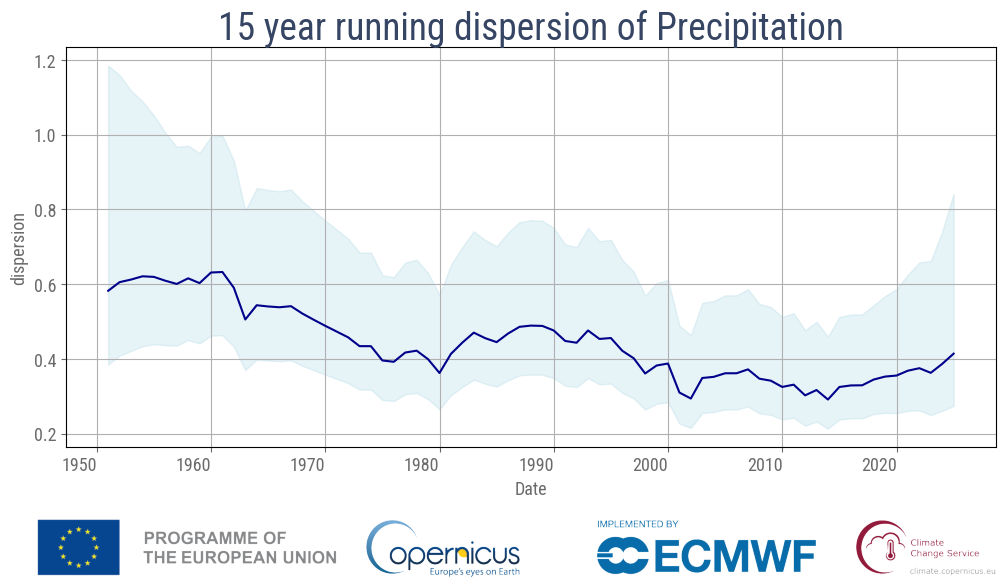

In [7]:
Plot.plot_timeserie(data=ts_ann_studyregion_15ym, datetime_col="year", value_col=value_col,
               title=f"15 year running {method} of {parameter}", x_label="Date", y_label=method, line_style='solid', ci=True);

## 3.2.d. Decide on which years to use if data is not homogeneous

### <font color='orange'>Specify the preferred time range based on the plot</font>

In [8]:
year_range = (1951, event_year)

### <font color='green'> Slice the annual time series on the given time range </font>

In [9]:
ts_ann_studyregion_subset = Utils.subset_gdf(gdf=ts_ann_studyregion, datetime_col="year", date_range=(year_range[0], year_range[1]))
ts_ann_studyregion_subset

,year,3_day_rolling_date,tp
0,1951,1951-08-23,72.611237
1,1952,1952-06-03,156.611115
2,1953,1953-10-05,56.201640
3,1954,1954-10-08,197.463386
4,1955,1955-09-30,209.504221
...,...,...,...
70,2021,2021-08-21,99.719591
71,2022,2022-06-21,56.343547
72,2023,2023-10-07,91.881753
73,2024,2024-07-01,127.713241


## 3.3 Conclude about the quality of ERA5
(and potentially other datasets) for the specific event definition and implications for the study results and the years to use, write into the output table in Notes & tables and the scientific report Section 2.1.
- a. For the region, check performance of the dataset, conclude on whether the data can be used with limited problems (“satisfactory”) or caution is necessary (“caution”) and conclude on a sentence in the scientific report
    - i. Temperature, include a statement on the performance of ERA5 for temperature based on Lopes et al. (2024) Conclusions from this paper are summarized here (attached to deliverable).
    - ii. Precipitation, include a statement on the performance of ERA5 for precipitation based on Lavers et al. (2022) Conclusions from this paper are summarized here (attached to deliverable).
    - iii. Other variable: if drought, base a general statement on temperature and precipitation, and/or perform literature study on the index and region specifically.
- b. For the use of years, using plots produced in Step 3.2.b visually check whether scale (temperature) or dispersion (precipitation) parameter show a trend and only use the stationary scale/dispersion-fit if the stationarity assumption is not obviously invalid in the sense that the trend is much greater than variability. Otherwise, a non-stationary scale- or
dispersion-parameter would be more appropriate (not part of OAO protocol). Add a sentence on caution on the results should be added to the scientific report Sec. 3.1 - see also Step 3.5b.iv

## 3.4 decide on which covariate to use
(normally this will only be GMST, smoothed with a 4-year running mean to remove the El Nino signal) and make sure the 4-year smoothed ERA5 GMST is updated up to the current month.
- a. C3S defines the 1850–1900 pre‑industrial global mean surface temperature to be 0.88 °C below the 1991–2020 ERA5 global average.

In [10]:
# # location of the gmst data
# gmst_url = "https://data.giss.nasa.gov/gistemp/tabledata_v4/GLB.Ts+dSST.csv"

# method = "mean"

In [11]:
# # import gmst data as seen in
# # https://github.com/maris-development/c3s-451/blob/development/input-notebooks/notebooks/gmst.ipynb

# datetime_col = "valid_time"
# gmst_col = "gmst"

# # read in the data
# gmst = (
#     pd.read_csv(
#         gmst_url,
#         na_values=["****", "***"],
#         index_col=0,
#         skiprows=1,
#         comment="#",
#     )
# )

# # unpivot the df
# gmst_monthly = (
#     pd.concat([
#         pd.DataFrame({
#             datetime_col: [datetime(y, i + 1, 1) for y in gmst.index],
#             gmst_col: gmst.iloc[:, i].values
#         })
#         for i in range(12)
#     ])
#     .sort_values(datetime_col)
#     .dropna(subset=[gmst_col])
#     .reset_index(drop=True)
# )
# gmst_monthly

# # change gmst column name to value_col
# gmst_monthly['t2m'] = gmst_monthly[gmst_col]
# gmst_monthly.drop(columns=[gmst_col], inplace=True)
# gmst_monthly = Utils.subset_gdf(gdf=gmst_monthly, datetime_col=datetime_col, date_range=(datetime(1951, 1, 1), event_end))
# gmst_monthly


In [12]:
event_end = datetime(2025, 6, 1)

your_api_key = '3cd17835-a572-4a0c-aaeb-334f01427616'
client = DataClient(cds_key=your_api_key, beacon_cache_url=None, beacon_token=None, mars_key=None)
gmst = client.gmst_xr(bbox=Utils.convert_bbox(*(90, 180, -90, -180)),time_range=(datetime(1951, 1, 1), event_end)) # bbox entire world, end datetime today

In [13]:
# # using geopandas
# gmst = client.gmst(bbox=bbox,time_range=(datetime(1951, 1, 1), event_end)) # bbox entire world, end datetime today
# gmst_weighted = Process.weighted_values(gmst, 't2m')
# gmst_monthly = Process.calculate_mean(df= gmst_weighted, value_col='t2m', groupby_col="valid_time")
# gmst_monthly

In [14]:
# xarray does not allow as to apply the weight in the same way as pandas/geopandas
# therefore we only return the weight and apply it later in the calculation
gmst_weights = Process.weighted_values(gmst, 't2m')
type(gmst_weights)

result = (
    gmst['t2m']
    .groupby('valid_time')
    .map(lambda da: da.weighted(gmst_weights).mean(dim=('latitude', 'longitude')))
    .drop_vars(['number', 'expver'], errors='ignore')
    .to_dataframe(name='t2m')
    .reset_index()
)
gmst_monthly = result
gmst_monthly

,valid_time,t2m
0,1951-01-01,11.523798
1,1951-02-01,11.683642
2,1951-03-01,12.563849
3,1951-04-01,13.642841
4,1951-05-01,14.849871
...,...,...
889,2025-02-01,13.356764
890,2025-03-01,14.059157
891,2025-04-01,14.962844
892,2025-05-01,15.792284


In [15]:
bbox = (15, -104, 28, -90)
bbox = Utils.convert_bbox(*bbox)

your_api_key = '3cd17835-a572-4a0c-aaeb-334f01427616'
gr_daily_clim = DataClient(your_api_key, beacon_cache_url='https://beacon-era5.maris.nl/').GET(parameter='Tmean', bbox=bbox, time_range=(datetime(1991, 1, 1), datetime(2020, 12, 31)), to_unit="c")

Connected to: https://beacon-era5.maris.nl/ server successfully
Beacon Version: 1.4.0
Fetching data for range: 1991-01-01 00:00:00 - 2020-12-31 00:00:00
Creating JSONQuery with from: FromTable(table='daily')
Running query: {"output": {"format": "parquet"}, "select": [{"column": "longitude", "alias": null}, {"column": "latitude", "alias": null}, {"column": "valid_time", "alias": null}, {"column": "t2m", "alias": null}], "filters": [{"and": [{"column": "longitude", "gt_eq": 256.0, "lt_eq": null}, {"column": "longitude", "gt_eq": null, "lt_eq": 270.0}, {"column": "latitude", "gt_eq": 15, "lt_eq": null}, {"column": "latitude", "gt_eq": null, "lt_eq": 28}]}, {"column": "valid_time", "gt_eq": "1991-01-01T00:00:00.000000", "lt_eq": "2020-12-31T00:00:00.000000"}], "distinct": null, "sort_by": null, "limit": null, "offset": null, "from": "daily"}


C:\Users\jasper\AppData\Local\Temp\ipykernel_32480\2452190064.py:5: DeprecationWarning: Use `self.fetch_data()` instead.
  gr_daily_clim = DataClient(your_api_key, beacon_cache_url='https://beacon-era5.maris.nl/').GET(parameter='Tmean', bbox=bbox, time_range=(datetime(1991, 1, 1), datetime(2020, 12, 31)), to_unit="c")


         longitude  latitude         t2m  doy           geometry valid_time
0            256.0     15.00  299.824799    1     POINT (256 15) 2025-01-01
1            256.0     15.25  299.766357    1  POINT (256 15.25) 2025-01-01
2            256.0     15.50  299.717682    1   POINT (256 15.5) 2025-01-01
3            256.0     15.75  299.674591    1  POINT (256 15.75) 2025-01-01
4            256.0     16.00  299.615967    1     POINT (256 16) 2025-01-01
...            ...       ...         ...  ...                ...        ...
1102660      270.0     27.00  293.202118  365     POINT (270 27) 2025-12-31
1102661      270.0     27.25  292.897369  365  POINT (270 27.25) 2025-12-31
1102662      270.0     27.50  292.563385  365   POINT (270 27.5) 2025-12-31
1102663      270.0     27.75  292.220886  365  POINT (270 27.75) 2025-12-31
1102664      270.0     28.00  291.856903  365     POINT (270 28) 2025-12-31

[1102665 rows x 6 columns]


In [ ]:
gr_daily_clim = gr_daily_clim.sort_values(by="valid_time")
clim31d = Process.calculate_climatology(gr_daily_clim, value_col='t2m', padding=15, event_date=event_end)
studyregion = gpd.read_file(os.path.join(your_save_directory, "sf_studyregion.shp"))
ts_clim31d_studyregion = Process.calculate_seasonal_cycle(clim31d=clim31d, studyregion=studyregion, month_range=(1, 12), value_col='t2m', datetime_col="valid_time", event_end=event_end)[0]
monthly_clim31d_studyregion = (ts_clim31d_studyregion.resample("M", on="valid_time")['t2m'].mean().rename_axis("valid_time").reset_index())
monthly_clim31d_studyregion["valid_time"] = monthly_clim31d_studyregion["valid_time"].dt.to_period("M").dt.to_timestamp()
monthly_clim31d_studyregion

C:\Users\jasper\AppData\Local\Temp\ipykernel_32480\2741511744.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_clim31d_studyregion = (ts_clim31d_studyregion.resample("M", on="valid_time")['t2m'].mean().rename_axis("valid_time").reset_index())


,valid_time,t2m
0,2025-01-01,292.629519
1,2025-02-01,293.611804
2,2025-03-01,295.174674
3,2025-04-01,297.049669
4,2025-05-01,298.528898
5,2025-06-01,299.038580
6,2025-07-01,299.032600
7,2025-08-01,299.008799
8,2025-09-01,298.251914
9,2025-10-01,296.987129


In [18]:
gmst_monthly_filled = Process.fill_missing_gmst_with_climatology(gmst_monthly, monthly_clim31d_studyregion)
gmst_yearly = gmst_monthly_filled.groupby(gmst_monthly_filled["valid_time"].dt.year)['t2m'].mean().reset_index()
# calculate the rolling mean Rolling windows of 4 years or should we take 5 years?, taking 2 years before, same year, ad 1 year after
#For last year it take 2 years before and same year
gmst_yearly_rolled = Process.calculate_rolling_window(gdf=gmst_yearly, value_col='t2m', datetime_col="valid_time", window=4, min_periods=2, centering=True, method="mean")
gmst_yearly_rolled_subset = Utils.subset_gdf(gdf=gmst_yearly_rolled, datetime_col="valid_time", date_range=(year_range[0], year_range[1]))
gmst_yearly_rolled_subset = gmst_yearly_rolled_subset.rename(columns={"valid_time": "year"})
gmst_yearly_rolled_subset

,year,t2m
0,1951,13.728952
1,1952,13.752025
2,1953,13.714341
3,1954,13.675981
4,1955,13.626704
...,...,...
70,2021,14.722935
71,2022,14.773311
72,2023,14.845150
73,2024,14.807603


In [19]:
# # Ensure datetime
# gmst_monthly["valid_time"] = pd.to_datetime(gmst_monthly["valid_time"])
# monthly_clim31d_studyregion["valid_time"] = pd.to_datetime(monthly_clim31d_studyregion["valid_time"])

# # Sort GMST
# gmst_monthly = gmst_monthly.sort_values("valid_time").reset_index(drop=True)

# last_year = gmst_monthly["valid_time"].dt.year.max()

# full_range = pd.date_range(
#     start=gmst_monthly["valid_time"].min(),
#     end=pd.Timestamp(year=last_year, month=12, day=1),
#     freq="MS"  # Month start
# )

# # Reindex GMST to this complete range
# gmst_complete = gmst_monthly.set_index("valid_time").reindex(full_range)
# gmst_complete.index.name = "valid_time"

# # Fill missing values using climatology + anomaly
# for idx in gmst_complete[gmst_complete["t2m"].isna()].index:
#     # Previous available GMST
#     prev_idx = gmst_complete.index[gmst_complete.index < idx][-1]
#     last_gmst = gmst_complete.loc[prev_idx, "t2m"]

#     # Climatology for previous month
#     prev_clim = monthly_clim31d_studyregion.loc[
#         monthly_clim31d_studyregion["valid_time"].dt.month == prev_idx.month,
#         "t2m"
#     ].iloc[0]

#     # Calculate anomaly
#     anomaly = last_gmst - prev_clim

#     # Climatology for missing month
#     missing_clim = monthly_clim31d_studyregion.loc[
#         monthly_clim31d_studyregion["valid_time"].dt.month == idx.month,
#         "t2m"
#     ].iloc[0]

#     # Fill missing GMST
#     gmst_complete.loc[idx, "t2m"] = missing_clim + anomaly

# # Reset index to column
# gmst_monthly_up = gmst_complete.reset_index()
# gmst_monthly_up


In [20]:
# # calculate the rolling mean
# gmst_monthly_rolled = calculate_rolling_window(gdf=gmst_monthly, value_col=gmst_col, datetime_col=datetime_col,
#                                                window=48, min_periods=24, centering=True, method=method)
# # select only the specified years
# gmst_monthly_rolled = subset_gdf(gdf=gmst_monthly_rolled, datetime_col=datetime_col, year_range=year_range)
# gmst_monthly_rolled

# gmst_yearly, rolled_gdf = calculate_yearly_value(gdf=gmst_monthly_rolled, value_col=gmst_col, datetime_col=datetime_col, yearly_value=method)
# gmst_yearly

In [21]:
merged_t2m_gmst = pd.merge(ts_ann_studyregion_subset, gmst_yearly_rolled_subset, left_on="year", right_on="year", how="inner")
# calculate anomaly relative to event year
ref_val = merged_t2m_gmst.loc[merged_t2m_gmst["year"] == event_year, 't2m'].values[0]
merged_t2m_gmst_anomaly = merged_t2m_gmst.copy()
merged_t2m_gmst_anomaly["gmst"] = merged_t2m_gmst_anomaly['t2m'] - ref_val
merged_t2m_gmst_anomaly.to_csv("../data/gmst_t2m.csv", index=False)
merged_t2m_gmst_anomaly

,year,3_day_rolling_date,tp,t2m,gmst
0,1951,1951-08-23,72.611237,13.728952,-1.123748
1,1952,1952-06-03,156.611115,13.752025,-1.100675
2,1953,1953-10-05,56.201640,13.714341,-1.138359
3,1954,1954-10-08,197.463386,13.675981,-1.176719
4,1955,1955-09-30,209.504221,13.626704,-1.225996
...,...,...,...,...,...
70,2021,2021-08-21,99.719591,14.722935,-0.129765
71,2022,2022-06-21,56.343547,14.773311,-0.079389
72,2023,2023-10-07,91.881753,14.845150,-0.007550
73,2024,2024-07-01,127.713241,14.807603,-0.045097


## 3.5 Apply statistical method
information for decisions on fit properties:
- a. fit data to statistical model, and check, at least by eye, that this fit agrees with the observed data points. Show this in a figure.
    - i. Gauss - soft extremes with low return periods that are not in the tail. Threshold μ (mu), scale parameter σ (sigma). Usually used for seasonal averages.
    - ii. GEV - largest observation from a large sample: annual/seasonal maximum, block maximum. Location parameter μ, scale parameter σ, shape parameter ξ. Usually used for 1-day to 14-day averages, annual (or seasonal) maximum
    - iii. For in-depth studies potentially use Lognormal, possibly better for precipitation.
- b. shift/scale with GMST or other proxy for anthropogenic forcing
    - i. for temperature extremes the distribution shifts due to global warming without changing the shape (variability: σ, ξ constant).
    - ii. for precipitation (and wind) extremes the distribution scales (variability over mean: dispersion parameter σ/μ and ξ constant).
    - iii. For precipitation with Lognormal use shift
    - iv. Use the visual check of scale or dispersion parameter (done in Step 3.3b): use the stationary scale/dispersion-fit if the stationarity assumption is not obviously invalid. Otherwise using a non-stationary scale- or dispersion-parameter would be more appropriate, and a sentence on caution on the results should be added to the scientific report Section. 3.1
    - v. decide on which covariate to use (normally GMST, smoothed with a 4-year running mean or a similar method to remove the El Nino signal)
    - vi. Include the datapoint of the event under study in the fit

### <font color='orange'>Please specify the following variables<font>

In [22]:
%%R -i event_year -i value_col
dist = "gev" #norm 
fit_type = "fixeddisp" #shift for temp, fixeddisp for precipitation # make fit_type automatically based on parameter selection
covnm = "gmst"
lower = FALSE
cooling_offset = 1.3 #fixed for now

In [23]:
%%R -i merged_t2m_gmst_anomaly 

df <- merged_t2m_gmst_anomaly

mdl <- fit_ns(dist = dist, type = fit_type, data = df, varnm = value_col, covnm = covnm, lower = lower, ev_year = event_year)

# the factual climate should have the GMST of the year in which the event occurred
cov_factual <- data.frame(gmst = df$gmst[df$year == event_year])

# the counterfactual climate can represent any alternative climate (WWA always uses a preindustrial climate, 1.3C cooler than the present)
cov_counterfactual <- data.frame(gmst = df$gmst[df$year == event_year] - cooling_offset)

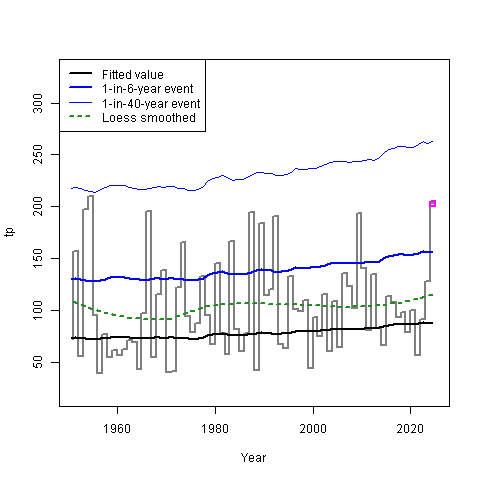

In [24]:
%%R

# what does the fitted trend look like over time?
# `add_loess = T` will add a nonparametric smoother - use this to check whether the fitted model captures the observed trend
plot_trend(mdl, add_loess = T, ylim = c(20,330))

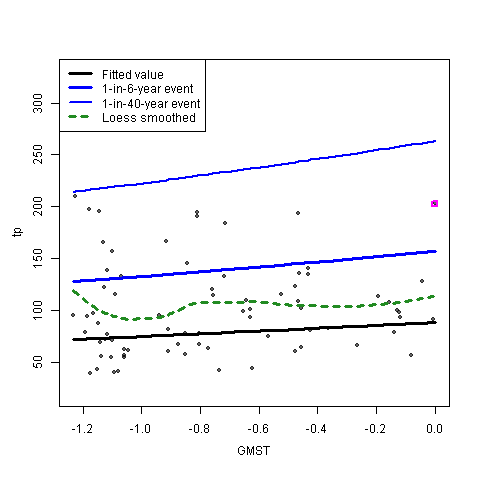

In [25]:
%%R
# what does the fitted trend look like vs GMST?
plot_covtrend(mdl, xcov = covnm, add_loess = T, ylim = c(20,330))

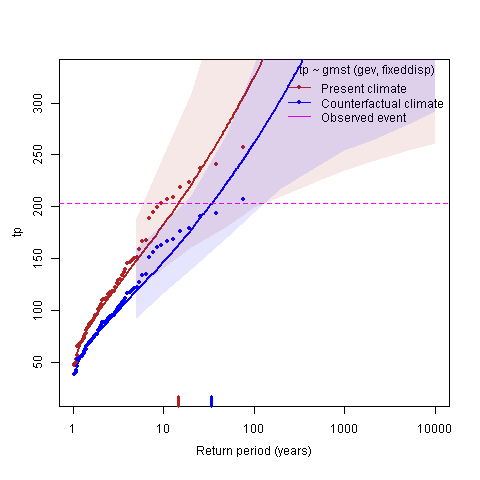

In [26]:
%%R
# How well does the model fit the data?
# the points should be close to the line - if they're not within the shaded region, the model is a poor fit
plot_returnlevels(mdl, cov_f = cov_factual, cov_cf = cov_counterfactual, xlim = c(1,10000),  ylim = c(20,330))

## 3.6 Observed probability and trend detection:
- a. Note down decision on the statistical method (see Step 3.5) in the Notes & Tables document
- b. Note dGMST, i.e. the difference between GMSTevent and GMSTpast, based on the Global Warming Index (https://www.globalwarmingindex.org) in 1 digits, e.g. 1.3 (this is the value in 2025). Check once a year that this value is still valid.
- c. Use all observational/reanalysis datasets that passed the quality checks (years see Step 3.2d). This is likely ERA5 and potentially also a station data time series.
- d. Note down/save variability or variability over mean (σ or σ/μ) and shape parameter ξ (for GEV) of the fit
- e. Note down return period in the current climate Yevent, e.g., 2025, and decide on the single rounded value that will be used for communication purposes and the model analyses – write this in the output table in Notes & Tables (bottom row). Rounding should correspond to the order of magnitude of the bandwidth, e.g., 13.876 (minimum 8.124 to maximum 20.573) should then be 14 (8-21.)
    - i. if necessary, make decision on using e.g. lower bound in case of too extreme return period. Then use this value in models analysis as well.
- f. Note down the threshold value corresponding to the event
- g. Note down probability ratio PR for dGMST, and change in intensity ΔI (absolute value for temperature, % for precipitation)

In [27]:
%%R

mdl_est <- cmodel_results (mdl, rp = 10, cov_f = cov_factual, cov_hist = cov_counterfactual)

print(mdl_est)

                 eval_disp_est eval_disp_lower eval_disp_upper eval_shape_est
tp ~ gmst (rp10)     0.3622095       0.2613986       0.3567664     0.05423868
                 eval_shape_lower eval_shape_upper rp_value attr_PR_est
tp ~ gmst (rp10)       0.02775063        0.4122397 183.3429    2.239694
                 attr_PR_lower attr_PR_upper attr_dI-abs_est attr_dI-abs_lower
tp ~ gmst (rp10)      2.080745      7.225562        35.89909          35.71952
                 attr_dI-abs_upper attr_dI-rel_est attr_dI-rel_lower
tp ~ gmst (rp10)           76.3548        24.34764          22.03584
                 attr_dI-rel_upper aic_eval aic_attr attr_nobs attr_nsamp
tp ~ gmst (rp10)          57.82125 482.4492 774.4397        75          5
                 attr_nfailed
tp ~ gmst (rp10)            0


J: we need to change this output
J: example can be found here
https://github.com/clairbarnes/wwa-current/blob/main/24-06-11_cam-heatwave/cam-heatwave_1R_trend-analysis.ipynb

check deze
https://github.com/clairbarnes/wwa-current/blob/main/00_training/25-03_mv-and-synthesis/mv.ipynb

In [ ]:
%%R
# use the built-in function to bootstrap the model results

boot_res <- boot_ci(mdl, cov_f = cov_factual, cov_cf = cov_counterfactual)
# these two lines might not even be needed
colnames(boot_res)[colnames(boot_res) == "2.5%"]  <- "lower"
colnames(boot_res)[colnames(boot_res) == "97.5%"] <- "upper"

# transpose to get the correct output format
boot_res_t <- data.frame(
    t(
        unlist(
            lapply(rownames(boot_res), function(rn) {
                setNames(
                    as.numeric(boot_res[rn, ]),
                    paste0(rn, "_", colnames(boot_res))
                )
            })
        )
    ),
    row.names = "era5"
)
print(boot_res_t)

# save as a .csv to look at them later
# this .csv is used for the Synthesis notebook
write.csv(boot_res_t, "../data/res-obs_era5.csv")

      mu0_est mu0_lower mu0_upper sigma0_est sigma0_lower sigma0_upper
era5 88.70773  74.11155  112.2279   35.02551     28.48205     43.34563
     alpha_gmst_est alpha_gmst_lower alpha_gmst_upper shape_est shape_lower
era5       14.86953        -14.30867          56.5116 0.1578477  -0.1385676
     shape_upper  disp_est disp_lower disp_upper event_magnitude_est
era5   0.3530681 0.3948417  0.3284443  0.4528499            202.9775
     event_magnitude_lower event_magnitude_upper return_period_est
era5              202.9775              202.9775          14.40254
     return_period_lower return_period_upper   PR_est  PR_lower PR_upper
era5            6.063741            120.2381 2.335508 0.1425413 10.12894
     dI_abs_est dI_abs_lower dI_abs_upper dI_rel_est dI_rel_lower dI_rel_upper
era5   39.74361    -39.55738     99.73876   24.34764    -16.30892     96.61639
      aic_est aic_lower aic_upper n_est n_lower n_upper
era5 774.4397  741.8094  796.2831    75     500       0


In [29]:
%%R

# comment out the top & bottom lines to see what the figures look like before saving them
png("../data/fig_obs-trend_era5.png", height = 480, width = 480); {
    plot_trend(mdl, add_loess = T, ylim = c(18,33), ylab = "Mean temperature (degC)", lwd = 2)
}; dev.off()

png("../data/fig_obs-gmsttrend_era5.png", height = 480, width = 480); {
    plot_covtrend(mdl, xcov = "gmst", add_loess = T, ylim = c(18,33), ylab = "Mean temperature (degC)", lwd = 2)
}; dev.off()

png("../data/fig_obs-returnlevels_era5.png", height = 480, width = 480); {
    plot_returnlevels(mdl, cov_f = cov_factual, cov_cf = cov_counterfactual, ylim = c(18,33), ylab = "Mean temperature (degC)",
                     legend_labels = c("2025", "Preindustrial"))
}; dev.off()

png 
  2 


In [30]:
%%R
rp_factual <- return_period(mdl, x = 89, fixed_cov = cov_factual)
rp_counterfactual <- return_period(mdl, x = 89, fixed_cov = cov_counterfactual)

cat("Return period (factual):\n")
print(rp_factual)
cat("\nReturn period (counterfactual):\n")
print(rp_counterfactual)


Return period (factual):
[1] 1.589692

Return period (counterfactual):
[1] 2.363892


In [31]:
%%R

# try fitting different distributions to compare which actually fits better
mdl_gev <- fit_ns(dist = "gev", type = "shift", data = df, varnm = value_col, covnm = "gmst", lower = F)
mdl_norm <- fit_ns(dist = "norm", type = "shift", data = df, varnm = value_col, covnm = "gmst", lower = F)

# use AIC to identify the model that fits better (lower score is better)
cat("AIC (GEV):", aic(mdl_gev), "\n")
cat("AIC (Normal):", aic(mdl_norm), "\n")

AIC (GEV): 772.0572 
AIC (Normal): 788.4359 


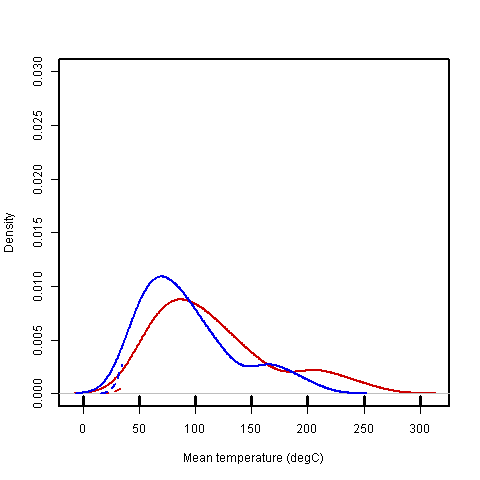

In [32]:
%%R

# the 'rwwa' package has a built-in function to transform all points into the factual or counterfactual climate
y_factual <- stransform(mdl, fixed_cov = cov_factual)
y_counterfactual <- stransform(mdl, fixed_cov = cov_counterfactual)

# it can also extract the model parameters for a fixed value of the covariates
pars_factual <- ns_pars(mdl, fixed_cov = cov_factual)
pars_counterfactual <- ns_pars(mdl, fixed_cov = cov_counterfactual)

#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# we can therefore plot the density of the temperatures as they would have been in today's climate, or in the counterfactual climate
par(lwd = 2)
plot(density(y_factual), col = "red3", ylim = c(0, 0.03), main = "", 
     xlab = "Mean temperature (degC)")

# factual model fit (dashed line)
x <- seq(15, 35, 0.1)
lines(x, devd(x, loc = pars_factual$loc, scale = pars_factual$scale, shape = pars_factual$shape),
      type = "l", col = "red3", lty = 2)

# counterfactual density and fit
lines(density(y_counterfactual), col = "blue2")
lines(x, devd(x, loc = pars_counterfactual$loc, scale = pars_counterfactual$scale, shape = pars_counterfactual$shape),
      type = "l", col = "blue2", lty = 2)

# add ticks for observed temperatures
rug(df$tmax, lwd = 3)

## 3.7 Literature review specific on the investigation of other possible climatic drivers of the event (modes of natural variability) for regions where they are important.
Steps a.i, b, c and d are essential, but if time allows it is useful to additionally do some of the optional steps.
- a. First find out what drivers influence (extremes in) the event type at the event location and its variability and trend, for example, using the following sources (see also Sec. 6a. Literature research)
    - i. Visually inspect teleconnection maps for average response of T/precip per month during years of high index https://confluence.ecmwf.int/display/COPSRV/ENSO+impacts+on+Europe and describe average impact over the region assessed if it is an ENSO year (see next step). In the maps “Global effects - temperature and precipitation” use
        - 7.a.i.1. Month of interest
        - 7.a.i.2. Variable of interest (top figures: temperature, bottom figures: precipitation)
        - 7.a.i.3. El Nino (figures left) or La Nina (figures right)
    - ii. OPTIONAL: Via IPCC AI chat https://www.climateqa.com/ e.g. by asking the question “what climate drivers influence the extremes, variability and trend of rainfall in Somalia” and, if El Niño is the answer, “what is the influence of El Niño on rainfall in Somalia?”. Any content derived from AI must be quality assured before inclusion in output.
    - iii. OPTIONAL: Search generally or in scholar.google.com for literature. ClimateQA can be used to summarise papers, in conjunction with careful proof reading of the output.
    - iv. OPTIONAL: Potentially ask this to the local experts.
- b. Assess what the current status of those drivers is on the current event. If e.g. ENSO is a driver, but ENSO is currently in a neutral state then, whilst ENSO influences the variability of the time series, it did not play a prominent role in the magnitude of the current event. Check the following and download the relevant graphics for the current status of ENSO and IOD.
    - i. ENSO
    - ii. IOD
- c. Decide whether an in-depth study should be considered and communicate this with the rest of the Team.
    - i. Investigate influence of modes of natural variability e.g. ENSO as 2nd covariate. The procedures in python notebook X can be followed.
- d. Summarise findings and decisions in scientific report Section 3.3 and summarise the findings in one sentence for the fact sheet.